# Custom Dropout Regularization

✅ The Custom Dropout and Custom Regularization features:

- A CustomDropout layer using TensorFlow ops.

- An L1ActivationRegularizer that penalizes large ReLU activations.

- A CNN on MNIST using these components.

## Setup & Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Load and Normalize Data

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Define Custom Regularizer

In [3]:
class CustomL1Regularizer(keras.regularizers.Regularizer):
    def __init__(self, l1=0.01):
        self.l1 = l1

    def __call__(self, x):
        return self.l1 * tf.reduce_sum(tf.abs(x))

    def get_config(self):
        return {'l1': self.l1}

## Define Custom Dropout Layer

In [4]:
class CustomDropout(layers.Layer):
    def __init__(self, rate):
        super(CustomDropout, self).__init__()
        self.rate = rate

    def call(self, inputs, training=False):
        if training:
            return tf.nn.dropout(inputs, rate=self.rate)
        return inputs

## Build and Compile Model

In [5]:
def build_model():
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        CustomDropout(0.3),
        layers.Flatten(),
        layers.Dense(64, activation='relu', kernel_regularizer=CustomL1Regularizer(0.001)),
        CustomDropout(0.3),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model()
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout (CustomDropout)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout_1                │ (None, 64)             │             0 │
│ (CustomDropout)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [6]:
early_stop = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.7729 - loss: 1.8307 - val_accuracy: 0.9157 - val_loss: 0.7281
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8643 - loss: 0.8670 - val_accuracy: 0.9383 - val_loss: 0.6077
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8861 - loss: 0.7665 - val_accuracy: 0.9459 - val_loss: 0.5744
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8964 - loss: 0.7275 - val_accuracy: 0.9527 - val_loss: 0.5548
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9022 - loss: 0.6975 - val_accuracy: 0.9560 - val_loss: 0.5222
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9098 - loss: 0.6670 - val_accuracy: 0.9596 - val_loss: 0.5110
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9133 - loss: 0.6531 - val_accuracy: 0.9617 - val_loss: 0.4952
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9180 - loss: 0.6376 - val_accuracy: 0

## Plot Accuracy & Loss Curves

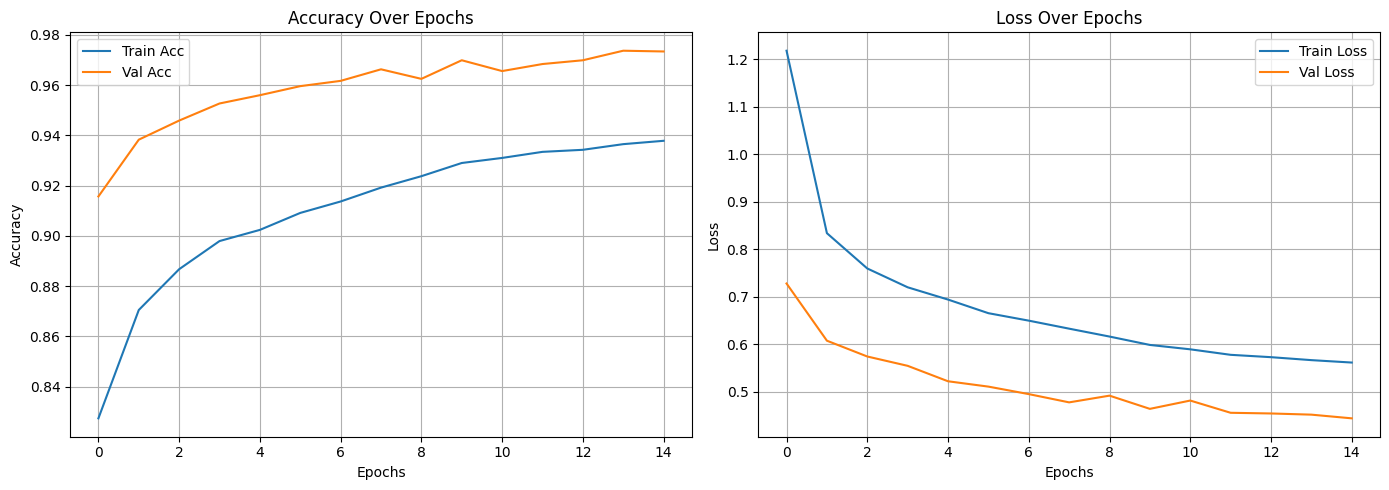

In [7]:
def plot_training(history):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training(history)

## Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


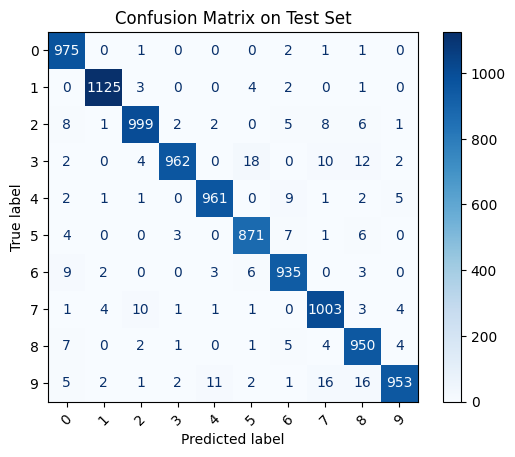

In [8]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.grid(False)
plt.show()

Custom Dropout and Regularization

📘 Overview

This Colab notebook demonstrates how to implement and use custom dropout and custom regularizers in Keras models. These allow more control over model behavior and can be tailored for specific tasks or research experiments.

🧪 Objective

To learn how to:

- Create a Custom Dropout layer using TensorFlow operations.

- Implement a Custom Regularizer that penalizes layer activations.

- Integrate both in a CNN model trained on the MNIST dataset.

🛠️ Implementation Details

Dataset: MNIST

Model Architecture:

Conv2D → CustomDropout → MaxPooling

Conv2D → CustomDropout → MaxPooling

Dense (with activation regularizer) → CustomDropout → Output

🔧 Components

CustomDropout Layer:

Overrides call() to apply dropout during both training and inference.

Uses tf.nn.dropout internally.

L1ActivationRegularizer:

Applies L1 penalty on layer activations (not weights).

Defined using tf.reduce_sum(tf.abs(x))

📈 Results

The model is trained with 3 custom dropout layers and one activation-regularized Dense layer. It shows strong regularization properties, with generalization enforced through:

- Dropout-based noise injection

- L1 penalty on activation magnitudes

- Test accuracy is reported after training.

🧠 Insights

Custom layers give fine control over model behavior.

Activation regularizers are useful to:

Avoid neuron saturation

Encourage sparse activation

Dropout helps with model robustness, especially under uncertainty.